# Homework Submission - Stage 12: Results Reporting and Delivery Design

**Audience:** an investment committee evaluating whether a prototype is ready for a limited pilot.

**Selected deliverable:** a written Markdown report. This notebook is the reproducible technical companion that creates the data, metrics, sensitivity table, three polished charts, and `reports/final_report.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

ROOT = Path.cwd()
PROCESSED = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
IMAGES = REPORTS / 'images'
for directory in [PROCESSED, REPORTS, IMAGES]:
    directory.mkdir(parents=True, exist_ok=True)

palette = {
    'Baseline': '#2F5D8A',
    'Higher costs': '#D28E2D',
    'Downside stress': '#7A8F45',
}

## 1. Self-contained scenario data and metric definitions

In [2]:
dates = pd.date_range('2025-01-31', periods=12, freq='ME')
baseline_returns = np.array([0.018, -0.012, 0.025, 0.008, 0.015, -0.006,
                             0.021, 0.011, -0.018, 0.027, 0.009, 0.014])
scenario_returns = {
    'Baseline': baseline_returns,
    'Higher costs': baseline_returns - 0.002,
    'Downside stress': baseline_returns + np.array(
        [0, 0, 0, -0.040, 0, 0, 0, 0, -0.050, 0, 0, 0]
    ),
}

rows = []
for scenario, monthly_returns in scenario_returns.items():
    for date, monthly_return in zip(dates, monthly_returns):
        rows.append({'date': date, 'scenario': scenario, 'monthly_return': monthly_return})
scenario_order = ['Baseline', 'Higher costs', 'Downside stress']
df = pd.DataFrame(rows)
df['scenario'] = pd.Categorical(df['scenario'], categories=scenario_order, ordered=True)
df = df.sort_values(['scenario', 'date']).reset_index(drop=True)
df['wealth_index'] = df.groupby('scenario')['monthly_return'].transform(lambda values: (1 + values).cumprod())
df['rolling_vol_3m'] = df.groupby('scenario')['monthly_return'].transform(
    lambda values: values.rolling(3).std() * np.sqrt(12)
)
data_path = PROCESSED / 'final_results.csv'
df.to_csv(data_path, index=False)
display(df.head())

/var/folders/pj/92h2g3sn161_6trjs5qp4c100000gn/T/ipykernel_65404/2473014441.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['wealth_index'] = df.groupby('scenario')['monthly_return'].transform(lambda values: (1 + values).cumprod())
/var/folders/pj/92h2g3sn161_6trjs5qp4c100000gn/T/ipykernel_65404/2473014441.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['rolling_vol_3m'] = df.groupby('scenario')['monthly_return'].transform(


,date,scenario,monthly_return,wealth_index,rolling_vol_3m
0,2025-01-31,Baseline,0.018,1.018000,NaN
1,2025-02-28,Baseline,-0.012,1.005784,NaN
2,2025-03-31,Baseline,0.025,1.030929,0.068088
3,2025-04-30,Baseline,0.008,1.039176,0.064156
4,2025-05-31,Baseline,0.015,1.054764,0.029597


In [3]:
def annualized_metrics(group: pd.DataFrame) -> pd.Series:
    returns = group['monthly_return']
    annual_return = (1 + returns).prod() - 1
    annual_volatility = returns.std(ddof=1) * np.sqrt(12)
    return pd.Series({
        'observations': len(group),
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'return_to_volatility': (returns.mean() * 12) / annual_volatility,
        'ending_wealth_per_dollar': group['wealth_index'].iloc[-1],
    })

metrics = df.groupby('scenario', sort=False, observed=True).apply(annualized_metrics, include_groups=False)
baseline_return = metrics.loc['Baseline', 'annual_return']
metrics['return_delta_vs_baseline'] = metrics['annual_return'] - baseline_return
metrics['volatility_delta_vs_baseline'] = metrics['annual_volatility'] - metrics.loc['Baseline', 'annual_volatility']
display(metrics.style.format({
    'annual_return': '{:.1%}',
    'annual_volatility': '{:.1%}',
    'return_to_volatility': '{:.2f}',
    'ending_wealth_per_dollar': '${:.3f}',
    'return_delta_vs_baseline': '{:+.1%}',
    'volatility_delta_vs_baseline': '{:+.1%}',
}))
sensitivity_path = PROCESSED / 'sensitivity_table.csv'
metrics.to_csv(sensitivity_path)

,observations,annual_return,annual_volatility,return_to_volatility,ending_wealth_per_dollar,return_delta_vs_baseline,volatility_delta_vs_baseline
scenario,,,,,,,
Baseline,12.000000,11.7%,5.0%,2.25,$1.117,+0.0%,+0.0%
Higher costs,12.000000,9.0%,5.0%,1.77,$1.090,-2.6%,+0.0%
Downside stress,12.000000,1.8%,9.6%,0.23,$1.018,-9.9%,+4.7%


The report uses compounded annual return, annualized sample volatility, and growth of one dollar. These are scenario summaries, not estimates from a live strategy. With only 12 synthetic monthly observations per scenario, precision statistics would create false confidence.

## 2. Chart 1 - monthly risk-return observations

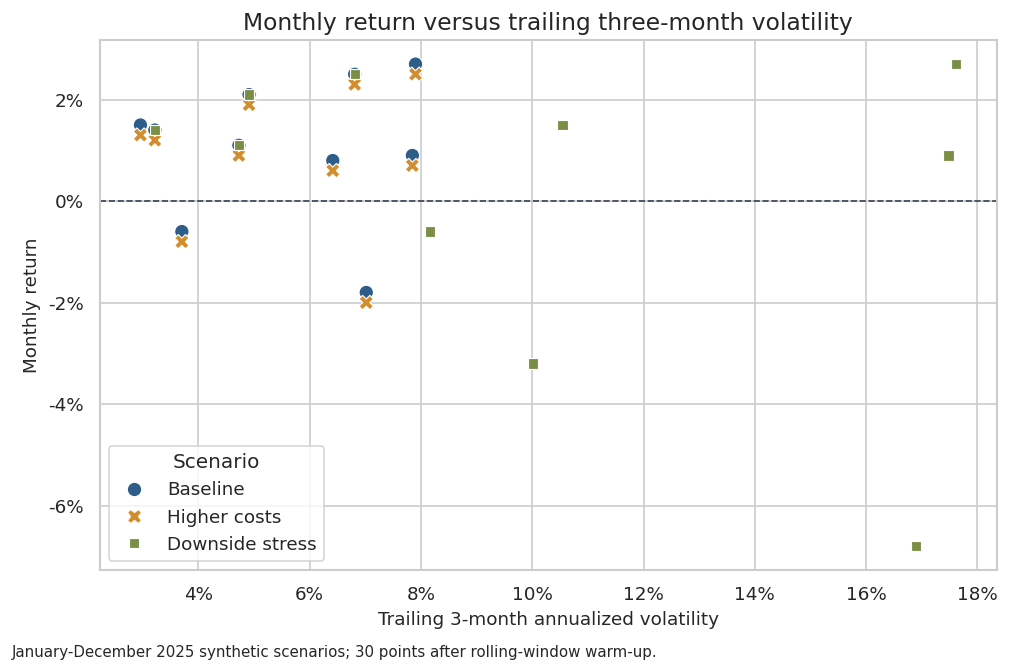

In [4]:
scatter_data = df.dropna(subset=['rolling_vol_3m'])
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(
    data=scatter_data,
    x='rolling_vol_3m',
    y='monthly_return',
    hue='scenario',
    style='scenario',
    palette=palette,
    s=75,
    ax=ax,
)
ax.axhline(0, color='#374151', linestyle='--', linewidth=1)
ax.set_title('Monthly return versus trailing three-month volatility')
ax.set_xlabel('Trailing 3-month annualized volatility')
ax.set_ylabel('Monthly return')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend(title='Scenario', loc='best')
fig.text(0.01, -0.01, 'January-December 2025 synthetic scenarios; 30 points after rolling-window warm-up.', fontsize=9)
fig.tight_layout()
risk_return_path = IMAGES / 'risk_return_monthly.png'
fig.savefig(risk_return_path, dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** stress observations extend toward higher trailing volatility and more negative monthly returns. The chart shows scenario mechanics, not a fitted efficient frontier. For the committee, the practical implication is that downside assumptions change both return and risk rather than simply shifting the expected return.

## 3. Chart 2 - cumulative wealth path

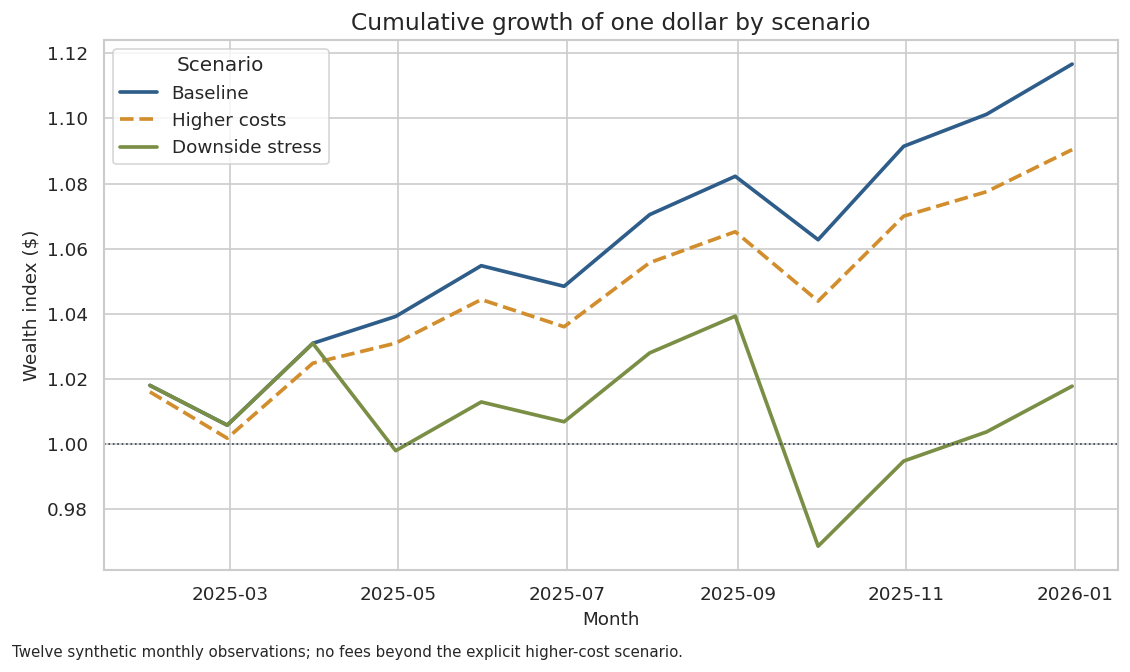

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for scenario in ['Baseline', 'Higher costs', 'Downside stress']:
    subset = df[df['scenario'] == scenario]
    ax.plot(subset['date'], subset['wealth_index'], label=scenario,
            color=palette[scenario], linewidth=2.2,
            linestyle='--' if scenario == 'Higher costs' else '-')
ax.axhline(1.0, color='#374151', linestyle=':', linewidth=1)
ax.set_title('Cumulative growth of one dollar by scenario')
ax.set_xlabel('Month')
ax.set_ylabel('Wealth index ($)')
ax.legend(title='Scenario')
fig.text(0.01, -0.01, 'Twelve synthetic monthly observations; no fees beyond the explicit higher-cost scenario.', fontsize=9)
fig.tight_layout()
wealth_path = IMAGES / 'cumulative_wealth.png'
fig.savefig(wealth_path, dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** small recurring costs compound into a visible gap, while two stress months create the dominant loss of terminal wealth. This makes the decision hinge more on downside tolerance and implementation cost than on the baseline headline alone.

## 4. Chart 3 - annual return sensitivity

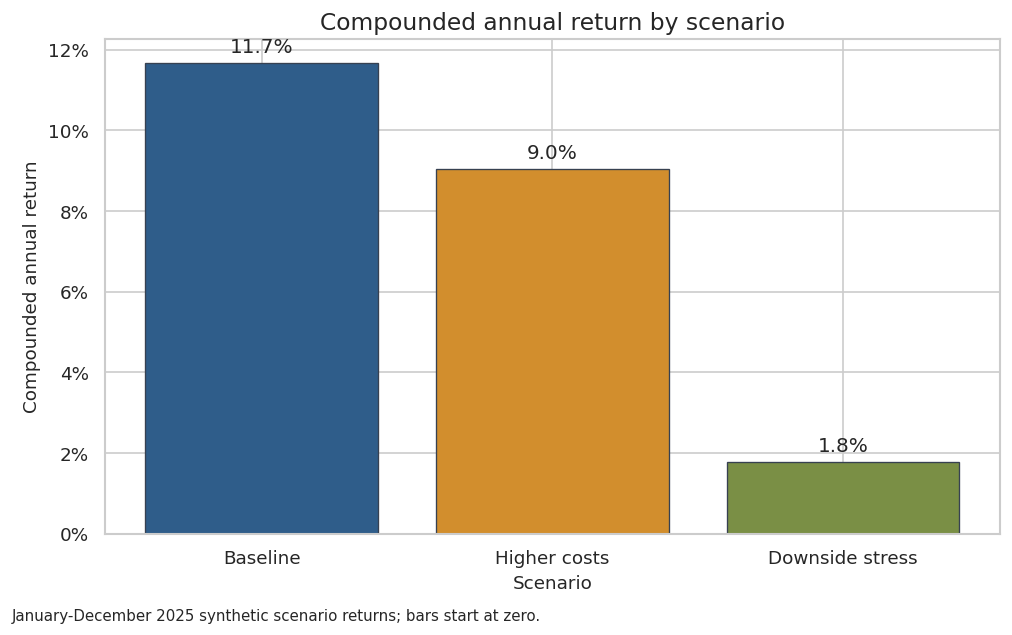

In [6]:
plot_metrics = metrics.reset_index()
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(
    plot_metrics['scenario'],
    plot_metrics['annual_return'],
    color=[palette[name] for name in plot_metrics['scenario']],
    edgecolor='#374151',
    linewidth=0.8,
)
ax.set_title('Compounded annual return by scenario')
ax.set_xlabel('Scenario')
ax.set_ylabel('Compounded annual return')
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.bar_label(bars, labels=[f'{value:.1%}' for value in plot_metrics['annual_return']], padding=4)
fig.text(0.01, -0.01, 'January-December 2025 synthetic scenario returns; bars start at zero.', fontsize=9)
fig.tight_layout()
sensitivity_chart_path = IMAGES / 'annual_return_sensitivity.png'
fig.savefig(sensitivity_chart_path, dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** the higher-cost scenario reduces annual return by about 2.6 percentage points, and the downside-stress scenario reduces it by about 9.9 points. The bar chart starts at zero so the magnitude comparison is not visually exaggerated.

## 5. Generate the stakeholder report

In [7]:
baseline = metrics.loc['Baseline']
higher_costs = metrics.loc['Higher costs']
downside = metrics.loc['Downside stress']

report = f"""# Pilot Before Scaling: Scenario Review

## Executive Summary

- **Baseline upside is positive but not decision-ready.** The 12-month synthetic baseline compounds to **{baseline['annual_return']:.1%}** with **{baseline['annual_volatility']:.1%}** annualized volatility; this is a scenario illustration, not a forecast.
- **Costs matter, but downside assumptions matter more.** Higher costs reduce return to **{higher_costs['annual_return']:.1%}** (**{higher_costs['return_delta_vs_baseline'] * 100:+.1f} percentage points** versus baseline). The downside-stress case falls to **{downside['annual_return']:.1%}** (**{downside['return_delta_vs_baseline'] * 100:+.1f} percentage points**) and volatility rises to **{downside['annual_volatility']:.1%}**.
- **Decision: approve only a limited, monitored pilot.** Do not make a full allocation from this evidence. First validate realized implementation cost, drawdown behavior, and performance on live out-of-sample data.

## Stress changes both the return and risk profile

The monthly scatter shows 30 scenario-month observations after the three-month rolling-volatility warm-up. Stress points move toward higher volatility and more negative monthly outcomes, so the downside case is not just a lower average-return assumption.

![Monthly risk-return observations](images/risk_return_monthly.png)

**What this means:** set an explicit risk budget and stress trigger before launch. A baseline return hurdle alone would miss the main scenario risk.

## Small recurring costs compound into a visible gap

The cumulative paths use the same baseline sequence. The higher-cost case subtracts 0.20 percentage points each month, while the downside case adds two discrete shocks. Ending wealth is **${baseline['ending_wealth_per_dollar']:.3f}** per dollar at baseline, **${higher_costs['ending_wealth_per_dollar']:.3f}** with higher costs, and **${downside['ending_wealth_per_dollar']:.3f}** under stress.

![Cumulative wealth by scenario](images/cumulative_wealth.png)

**What this means:** pilot monitoring should separate recurring implementation drag from event-driven losses because the remedies differ.

## Annual outcome is most sensitive to downside stress

The exact scenario comparison is:

| Scenario | Annual return | Annual volatility | Return delta vs baseline |
|---|---:|---:|---:|
| Baseline | {baseline['annual_return']:.1%} | {baseline['annual_volatility']:.1%} | - |
| Higher costs | {higher_costs['annual_return']:.1%} | {higher_costs['annual_volatility']:.1%} | {higher_costs['return_delta_vs_baseline'] * 100:+.1f} pp |
| Downside stress | {downside['annual_return']:.1%} | {downside['annual_volatility']:.1%} | {downside['return_delta_vs_baseline'] * 100:+.1f} pp |

![Annual-return sensitivity](images/annual_return_sensitivity.png)

**What this means:** the baseline conclusion is fragile to two adverse months. A full allocation is not justified until the downside scenario is tested against real historical or live observations.

## Recommended Next Steps - What This Means for You

1. Run a limited pilot with pre-set maximum drawdown, cost, and volatility limits.
2. Replace the synthetic monthly series with live or historical out-of-sample returns before any scale-up decision.
3. Recompute scenario metrics after realized costs and at least one stressed period are observed.
4. Escalate for review if rolling volatility approaches the stress scenario or if return falls below the higher-cost case.

## Further Questions

- Are the two stress shocks realistic for the intended asset, holding period, and liquidity?
- What turnover, slippage, tax, and capacity assumptions produce the 0.20% monthly cost case?
- Which benchmark and drawdown threshold define a successful pilot?

## Assumptions and Risks

- All 36 rows are synthetic and cover only January-December 2025 at monthly grain. They demonstrate communication and sensitivity design; they do not estimate an investable opportunity.
- Annual return is the compounded product of 12 monthly returns. Volatility is monthly sample standard deviation multiplied by the square root of 12.
- The return-to-volatility ratio assumes a zero risk-free rate and independent, identically distributed monthly returns; those assumptions are not established.
- The scenarios are designed inputs, not probabilities. No claim is made that one scenario is more likely than another.
- Past or simulated results do not establish causality, persistence, or future performance.
"""
report = '\n'.join(line[12:] if line.startswith('            ') else line for line in report.splitlines())
report_path = REPORTS / 'final_report.md'
report_path.write_text(report.strip() + '\n', encoding='utf-8')
print('Saved report:', report_path)
print('Saved images:', sorted(path.name for path in IMAGES.glob('*.png')))

Saved report: /Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework12/reports/final_report.md
Saved images: ['annual_return_sensitivity.png', 'cumulative_wealth.png', 'risk_return_monthly.png']


## 6. Delivery checks

The report is decision-first, contains three adjacent chart interpretations, quantifies both alternate scenarios against baseline, labels the data as synthetic, includes a plain-language decision implication, and keeps exact reproducibility details in `reports/README.md` and `reports/source_notes.md`.

In [8]:
required_outputs = [
    REPORTS / 'final_report.md',
    REPORTS / 'README.md',
    REPORTS / 'source_notes.md',
    IMAGES / 'risk_return_monthly.png',
    IMAGES / 'cumulative_wealth.png',
    IMAGES / 'annual_return_sensitivity.png',
    PROCESSED / 'final_results.csv',
    PROCESSED / 'sensitivity_table.csv',
]
output_checks = pd.Series({str(path.relative_to(ROOT)): path.exists() and path.stat().st_size > 0 for path in required_outputs})
display(output_checks.rename('exists_and_nonempty').to_frame())
assert output_checks.all()
assert len(df) == 36
assert (metrics['observations'] == 12).all()
assert metrics.loc['Higher costs', 'annual_return'] < metrics.loc['Baseline', 'annual_return']
assert metrics.loc['Downside stress', 'annual_volatility'] > metrics.loc['Baseline', 'annual_volatility']

,exists_and_nonempty
reports/final_report.md,True
reports/README.md,True
reports/source_notes.md,True
reports/images/risk_return_monthly.png,True
reports/images/cumulative_wealth.png,True
reports/images/annual_return_sensitivity.png,True
data/processed/final_results.csv,True
data/processed/sensitivity_table.csv,True
